In [1]:
import matplotlib.pyplot as plt
import networkx as nx
from torch_geometric.datasets import Planetoid

/home/njz/study_graph/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## データ用意

In [2]:
dataset = Planetoid(root="./dataset", name="Cora", split="full")

In [3]:
print(f"{type(dataset)}")
print(f"{type(dataset._data)}")

<class 'torch_geometric.datasets.planetoid.Planetoid'>
<class 'torch_geometric.data.data.Data'>


In [4]:
from collections import Counter
from torch_geometric.utils.convert import to_networkx

In [5]:
cora_network = to_networkx(dataset._data, node_attrs=["y"])
print(f"{type(cora_network)}")
print(f"ノード数: {cora_network.number_of_nodes():,}")
print(f"ノード数: {cora_network.number_of_edges():,}")

<class 'networkx.classes.digraph.DiGraph'>
ノード数: 2,708
ノード数: 10,556


In [6]:
# 重い
# nx.draw(cora_network, node_size=10)

In [7]:
labels = nx.get_node_attributes(cora_network, "y")
label_counter = Counter(labels.values())

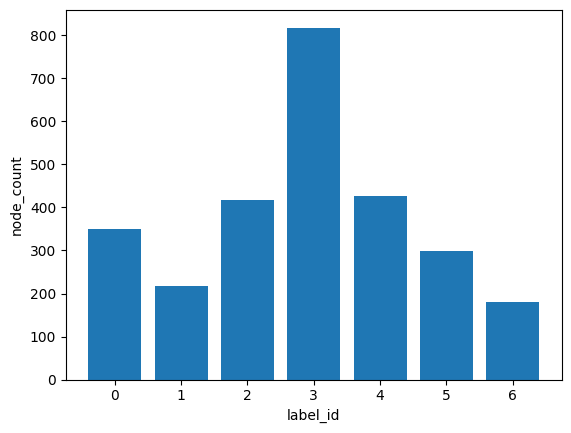

In [8]:
plt.bar(
    [k for k, _ in sorted(label_counter.items())],
    [v for _, v in sorted(label_counter.items())],
)
plt.xlabel("label_id")
plt.ylabel("node_count")
plt.show()

## 前処理

In [9]:
# 分割
from torch_geometric.transforms import RandomNodeSplit

# ノードを学習データとテストデータに分割
node_splitter = RandomNodeSplit(
    split="train_rest",
    num_splits=1,
    num_val=0.0,
    num_test=0.4,
    key="y"
)
splitted_data = node_splitter(dataset._data)

In [10]:
print(splitted_data.node_attrs())
print(splitted_data.train_mask)
print(splitted_data.test_mask)

['y', 'test_mask', 'x', 'train_mask', 'val_mask']
tensor([ True, False,  True,  ...,  True,  True,  True])
tensor([False,  True, False,  ..., False, False, False])


## node2vecによる分散表現の学習

In [11]:
import torch
from torch_geometric.nn import Node2Vec

In [12]:
device = "cuda" if torch.cuda.is_available() else "cpu"
n2v_model = Node2Vec(
    splitted_data.edge_index,  # 教師データは構造そのもの！
    embedding_dim=64,
    walk_length=5,
    context_size=5,
    walks_per_node=10,
    num_negative_samples=1,
    p=1,
    q=1,
    sparse=False,
).to(device)
n2v_optimizer = torch.optim.Adam(
    list(n2v_model.parameters()), lr=0.01
)

In [13]:
from tqdm import tqdm

def train_n2v() -> float:
    n2v_model.train()
    total_loss = 0.0
    loader = n2v_model.loader(batch_size=8, shuffle=True)
    
    
    for pos_rw, neg_rw in tqdm(loader):
        n2v_optimizer.zero_grad()
        
        loss = n2v_model.loss(
            pos_rw.to(device),
            neg_rw.to(device),
        )
        loss.backward()
        n2v_optimizer.step()
        total_loss += loss.item()
    
    return total_loss / len(loader)

In [14]:
# 学習の実行
for epoch in range(30):
    loss = train_n2v()
    print(f"train loss : {loss:.4f}")

100%|██████████| 339/339 [00:01<00:00, 205.08it/s]


train loss : 5.5430


100%|██████████| 339/339 [00:01<00:00, 244.66it/s]


train loss : 3.7109


100%|██████████| 339/339 [00:01<00:00, 280.79it/s]


...

train loss : 0.8757


100%|██████████| 339/339 [00:01<00:00, 301.29it/s]


train loss : 0.8813


100%|██████████| 339/339 [00:01<00:00, 302.70it/s]

train loss : 0.8761


## ロジスティック回帰との組み合わせ

In [15]:
embedding_matrix = n2v_model.embedding(
    torch.arange(splitted_data.num_nodes).to(device)
)
print(embedding_matrix.shape)

torch.Size([2708, 64])


In [16]:
embedding_matrix

tensor([[ 0.0185,  0.6269,  0.1104,  ..., -0.1573,  0.0599, -0.4033],
        [-0.0655,  0.7434,  0.2534,  ..., -0.5632,  0.0222, -0.5723],
        [-0.5772,  0.6043, -0.6683,  ..., -0.3232,  0.4892, -0.1155],
        ...,
        [-0.0369,  0.4859,  0.1338,  ..., -0.3300, -0.2424,  0.2452],
        [-0.0620,  0.1546,  0.1965,  ...,  0.3813,  0.1234,  0.0958],
        [-0.0807, -0.1735, -0.0063,  ...,  0.5595, -0.6007,  0.3562]],
       device='cuda:0', grad_fn=<EmbeddingBackward0>)

### あらかじめ与えられた特徴量のみ

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

In [18]:
baseline_classifier = LogisticRegression(
    max_iter=1000,
    random_state=0,
)
x_train = splitted_data.x[splitted_data.train_mask].numpy()
y_train = splitted_data.y[splitted_data.train_mask].numpy()
baseline_classifier.fit(x_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,0
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [19]:
# 評価データへの推論
x_test = splitted_data.x[splitted_data.test_mask].numpy()
y_true = splitted_data.y[splitted_data.test_mask].numpy()
y_pred = baseline_classifier.predict(x_test)

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.59      0.63      0.61       123
           1       0.82      0.60      0.70        81
           2       0.92      0.81      0.86       159
           3       0.73      0.88      0.80       344
           4       0.80      0.73      0.76       190
           5       0.78      0.68      0.72       122
           6       0.67      0.62      0.65        64

    accuracy                           0.76      1083
   macro avg       0.76      0.71      0.73      1083
weighted avg       0.76      0.76      0.75      1083



### 分散表現を追加

In [23]:
n2v_classifier = LogisticRegression(
    max_iter=1000,
    random_state=0,
)
x_train = (
    torch.cat(
        (
            splitted_data.x[splitted_data.train_mask].to(device),
            embedding_matrix[splitted_data.train_mask].to(
                device
            ),  # 学習した埋め込み表現を連結
        ),
        dim=1,
    )
    .detach()
    .cpu()
    .numpy()
)
y_train = splitted_data.y[splitted_data.train_mask].numpy()
n2v_classifier.fit(x_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,0
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [26]:
# 評価データへの推論
x_test = torch.cat(
        (
            splitted_data.x[splitted_data.test_mask].to(device),
            embedding_matrix[splitted_data.test_mask].to(
                device
            ),  # 学習した埋め込み表現を連結
        ),
        dim=1,
).detach().cpu().numpy()
y_true = splitted_data.y[splitted_data.test_mask].numpy()
y_pred = n2v_classifier.predict(x_test)

print(classification_report(y_true, y_pred))


              precision    recall  f1-score   support

           0       0.64      0.71      0.67       123
           1       0.84      0.77      0.80        81
           2       0.92      0.88      0.90       159
           3       0.80      0.91      0.85       344
           4       0.85      0.75      0.80       190
           5       0.84      0.71      0.77       122
           6       0.71      0.64      0.67        64

    accuracy                           0.81      1083
   macro avg       0.80      0.77      0.78      1083
weighted avg       0.81      0.81      0.80      1083

